# Entrega #2 Proyecto redes Neuronales
## *Clasificación de Texto con Redes Neuronales*
### **Dataset**: Twitter US Airline Sentiment Dataset

Mensajes de Twitter en inglés sobre las principales aerolíneas estadounidenses clasificados por sentimientos como: positive, negative, neutral. Se recopilaron datos de Twitter en febrero de 2015

**Fuente:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

Oscar David Cuaical Lopez

202270657

cuaical.oscar@correounivalle.edu.co

# Importación de librerías y carga de datos

En esta sección se importan las librerías necesarias para el análisis de datos, procesamiento de texto y construcción de modelos de aprendizaje profundo.

Se descargan las *stopwords* en inglés para su uso en la limpieza del texto.

## Carga del dataset

Se carga un conjunto de datos de tweets sobre aerolíneas desde una fuente externa y se seleccionan las columnas relevantes:

- `text`: contenido del tweet  
- `airline_sentiment`: sentimiento asociado  

## Análisis inicial

Se revisa la distribución de las clases para identificar posibles desbalances en el dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Configuración inicial
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Carga del Dataset
url = "https://raw.githubusercontent.com/oscar-230/Dataset-Twitter/main/Tweets.csv"
df = pd.read_csv(url)

# Nos quedamos solo con las columnas relevantes
df = df[['text', 'airline_sentiment']]

# Verificamos el desbalance
print("Distribución de clases original:")
print(df['airline_sentiment'].value_counts())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Distribución de clases original:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


#Preprocesamiento de Texto (Limpieza)

Se define una función para preprocesar los tweets y reducir el ruido en los datos. Este proceso incluye:

- Conversión de texto a minúsculas  
- Eliminación de menciones de usuarios  
- Eliminación de URLs  
- Eliminación de caracteres especiales y números  
- Normalización de espacios  
- Eliminación de *stopwords*  

Luego, la función se aplica a la columna `text` para generar una nueva columna `text_clean` con el texto limpio.

Finalmente, se muestra un ejemplo comparando un tweet original con su versión procesada.

In [ ]:
def limpiar_texto(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar menciones de usuarios (@VirginAmerica)
    text = re.sub(r'@\w+', '', text)
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Eliminar caracteres especiales y números
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    # Eliminar espacios extra
    text = re.sub(r'\s+', ' ', text).strip()
    # Eliminar stopwords para reducir ruido en RNNs simples
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Aplicar limpieza
df['text_clean'] = df['text'].apply(limpiar_texto)

print("\nEjemplo original:", df['text'].iloc[1])
print("Ejemplo limpio:  ", df['text_clean'].iloc[1])


Ejemplo original: @VirginAmerica plus you've added commercials to the experience... tacky.
Ejemplo limpio:   plus added commercials experience tacky


# Tokenización y Padding

Se definen los parámetros principales para el procesamiento del texto, como el tamaño del vocabulario, la longitud máxima de las secuencias y la dimensión de los embeddings.

Luego, se realiza la tokenización de los textos limpios, convirtiendo cada palabra en un índice numérico. Se limita el vocabulario a las palabras más frecuentes.

Posteriormente, los textos se transforman en secuencias y se ajustan a una longitud fija mediante *padding*.

Finalmente, las etiquetas de sentimiento se convierten a formato numérico utilizando ***One-Hot Encoding***, y se muestran las dimensiones de los datos de entrada y salida.

In [ ]:
# Parámetros
MAX_NB_WORDS = 5000    # Consideramos las 5000 palabras más frecuentes
MAX_SEQUENCE_LENGTH = 50 # Longitud máxima del tweet
EMBEDDING_DIM = 100    # Dimensión del vector denso

# Tokenización
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)
tokenizer.fit_on_texts(df['text_clean'].values)
word_index = tokenizer.word_index
print(f'Se encontraron {len(word_index)} tokens únicos.')

# Convertir a secuencias y hacer Padding
X = tokenizer.texts_to_sequences(df['text_clean'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)

# Codificar etiquetas (One-Hot Encoding)
# Mapeo: negative -> 0, neutral -> 1, positive -> 2
Y = pd.get_dummies(df['airline_sentiment']).values
print('Forma del tensor de datos (X):', X.shape)
print('Forma del tensor de etiquetas (Y):', Y.shape)

<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:7: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipython-input-4266035918.py:7: SyntaxWarning: invalid escape sequence '\]'
  tokenizer = Tokenizer(num_words=MAX_NB_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)


Se encontraron 11030 tokens únicos.
Forma del tensor de datos (X): (14640, 50)
Forma del tensor de etiquetas (Y): (14640, 3)


# División de datos y balance de clases

El dataset se divide en tres subconjuntos:

- Entrenamiento (70%)  
- Validación (15%)  
- Prueba (15%)  

La división se realiza de forma estratificada para mantener la proporción de clases en cada conjunto.

Luego, se calculan los pesos de clase para manejar el desbalance en los datos. Para ello, las etiquetas se convierten de formato *one-hot* a valores enteros.

Estos pesos se utilizarán durante el entrenamiento del modelo para dar mayor importancia a las clases menos representadas.

In [ ]:
# División: 70% Entreno, 15% Validación, 15% Test
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp)

# Calcular Pesos de Clase (Para el desbalance)
# Necesitamos convertir Y_train de one-hot a enteros para calcular los pesos
y_ints = np.argmax(Y_train, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_ints),
    y=y_ints
)
class_weights_dict = dict(enumerate(class_weights))
print("Pesos de clase calculados (0:Neg, 1:Neu, 2:Pos):", class_weights_dict)

Pesos de clase calculados (0:Neg, 1:Neu, 2:Pos): {0: np.float64(0.5316731517509727), 1: np.float64(1.5749193176579068), 2: np.float64(2.065296251511487)}


# Definición de modelos y control de overfitting

Se establecen varios parámetros para reducir el sobreajuste (*overfitting*), como la regularización L2, el uso de *dropout*, una menor cantidad de neuronas y una tasa de aprendizaje más baja.

Se definen dos arquitecturas de redes neuronales:

## Modelo SimpleRNN

Este modelo utiliza una capa de *Embedding*, seguida de *SpatialDropout* y una capa recurrente SimpleRNN. Es una arquitectura más sencilla, útil como línea base.

## Modelo LSTM

Este modelo incorpora una capa LSTM, que es más robusta para capturar dependencias en secuencias de texto. Además, incluye regularización L2 y altos valores de *dropout* para mejorar la generalización.

Ambos modelos finalizan con una capa densa con activación *softmax* para la clasificación en tres categorías.

Finalmente, se crean las instancias de ambos modelos para su posterior entrenamiento.

In [ ]:
# Configuración Anti-Overfitting
REG_L2 = 0.001       # Penalización L2 (Ayuda a mantener la loss de validación baja)
DROP_RATE = 0.5      # Apagar el 50% de las neuronas en cada paso
UNITS = 32           # Menos neuronas para evitar memorización
LR = 0.0001          # Tasa de aprendizaje más lenta

# Definicion de red neuronal Simple
def simple_rnn():
    model = Sequential()
    model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
    model.add(SpatialDropout1D(0.5))

    # SimpleRNN:
    model.add(SimpleRNN(32,
                        dropout=0.3,
                        recurrent_dropout=0.3))

    model.add(Dense(3, activation='softmax'))

    # Usamos Learning Rate estándar (0.0001) para que aprenda un poco mas lento y no haya sobreajuste
    optimizer = Adam(learning_rate=0.0001)

    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Definicion de red neuronal LSTM
def lstm_network():
    model = Sequential()
    model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
    model.add(SpatialDropout1D(DROP_RATE))

    # Capa LSTM con L2 y alto Dropout
    model.add(LSTM(UNITS,
                   dropout=DROP_RATE,
                   recurrent_dropout=DROP_RATE,
                   kernel_regularizer=l2(REG_L2),
                   recurrent_regularizer=l2(REG_L2),
                   bias_regularizer=l2(REG_L2)))

    model.add(Dense(3, activation='softmax'))

    optimizer = Adam(learning_rate=LR)

    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Entrenamos las redes
model_rnn = simple_rnn()
model_lstm = lstm_network()

# Entrenamiento de los modelos

Se entrenan ambos modelos (SimpleRNN y LSTM) utilizando los datos de entrenamiento y validación.

Durante el entrenamiento:

- Se define un número máximo de épocas  
- Se utiliza un tamaño de lote (*batch size*) de 32  
- Se aplican pesos de clase para manejar el desbalance  
- Se emplea *Early Stopping* para detener el entrenamiento si la pérdida de validación no mejora, evitando el sobreajuste  

Además, se restauran los mejores pesos obtenidos durante el entrenamiento.

Se guarda el historial de entrenamiento de cada modelo para su posterior análisis.

In [ ]:
print("--- Entrenando RNN Simple ---")
history_rnn = model_rnn.fit(
    X_train, Y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val, Y_val),
    class_weight=class_weights_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)


print("\n--- Entrenando LSTM ---")
history_lstm = model_lstm.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, Y_val),
    class_weight=class_weights_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

--- Entrenando RNN Simple ---
Epoch 1/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.3417 - loss: 1.2299 - val_accuracy: 0.2140 - val_loss: 1.1701
Epoch 2/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3571 - loss: 1.1977 - val_accuracy: 0.2291 - val_loss: 1.1580
Epoch 3/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.3554 - loss: 1.1687 - val_accuracy: 0.2291 - val_loss: 1.1486
Epoch 4/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.3481 - loss: 1.1847 - val_accuracy: 0.2773 - val_loss: 1.1227
Epoch 5/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3697 - loss: 1.1467 - val_accuracy: 0.2609 - val_loss: 1.1267
Epoch 6/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.3859 - loss: 1.1269 - val_accuracy: 0.2914 - val_loss: 1.1124
Epoch 7/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4007 - loss: 1.1143 - val_accuracy: 0.2969 - val_loss: 1.1073
Epoch 8/40
321/321 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy:

##7. Evaluación y Comparación de los modelos

Se define una función para graficar el desempeño de los modelos durante el entrenamiento.

Se muestran dos métricas principales:

- **Accuracy**: mide la precisión del modelo en entrenamiento y validación  
- **Loss**: indica el error del modelo en ambos conjuntos  

Estas gráficas permiten analizar el comportamiento del modelo, detectar sobreajuste y comparar el rendimiento entre entrenamiento y validación.

Finalmente, se generan las gráficas para los modelos SimpleRNN y LSTM.

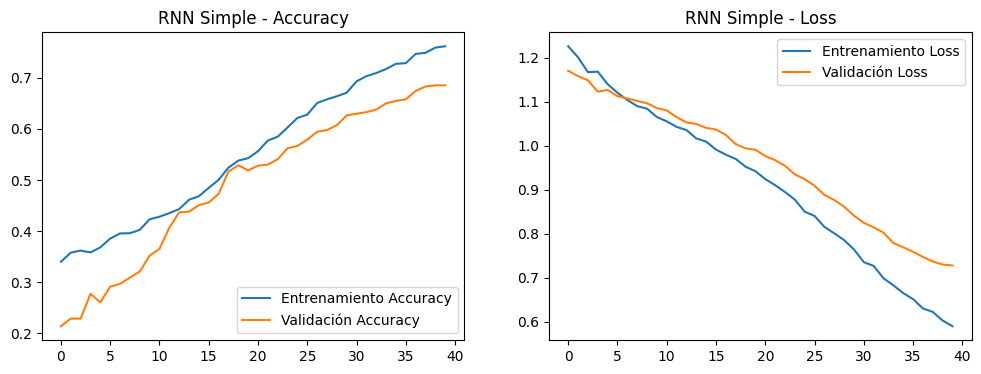

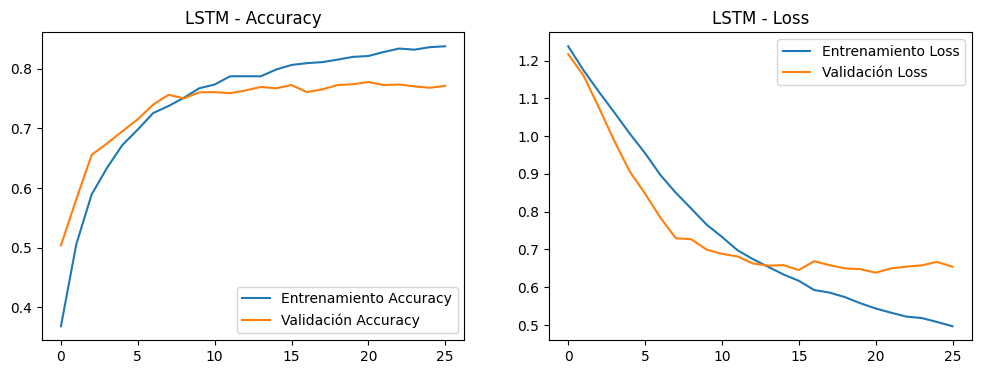

In [ ]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Gráfica de Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Entrenamiento Accuracy')
    plt.plot(epochs_range, val_acc, label='Validación Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    # Gráfica de Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Entrenamiento Loss')
    plt.plot(epochs_range, val_loss, label='Validación Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.show()

# Graficar
plot_history(history_rnn, "RNN Simple")
plot_history(history_lstm, "LSTM")

# Evaluación de los modelos

Se define una función para evaluar el rendimiento de los modelos utilizando el conjunto de prueba.

Primero, se generan las predicciones y se convierten a clases utilizando el valor máximo de probabilidad.

Luego, se muestra un **reporte de clasificación**, que incluye métricas como precisión, recall y F1-score para cada clase.

Además, se construye una **matriz de confusión**, que permite visualizar el número de predicciones correctas e incorrectas por clase.

Finalmente, se aplica esta evaluación a los modelos SimpleRNN y LSTM para comparar su desempeño.

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

--- Reporte de Clasificación: RNN Simple ---
              precision    recall  f1-score   support

    negative       0.84      0.74      0.79      1376
     neutral       0.45      0.50      0.48       465
    positive       0.49      0.65      0.56       355

    accuracy                           0.68      2196
   macro avg       0.60      0.63      0.61      2196
weighted avg       0.70      0.68      0.68      2196



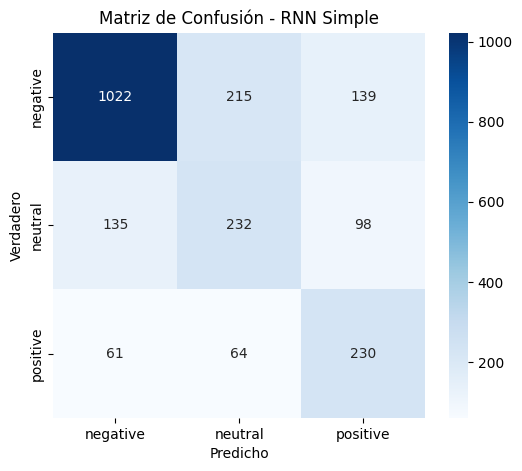

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

--- Reporte de Clasificación: LSTM ---
              precision    recall  f1-score   support

    negative       0.87      0.82      0.85      1376
     neutral       0.56      0.65      0.60       465
    positive       0.66      0.70      0.68       355

    accuracy                           0.76      2196
   macro avg       0.70      0.72      0.71      2196
weighted avg       0.77      0.76      0.77      2196



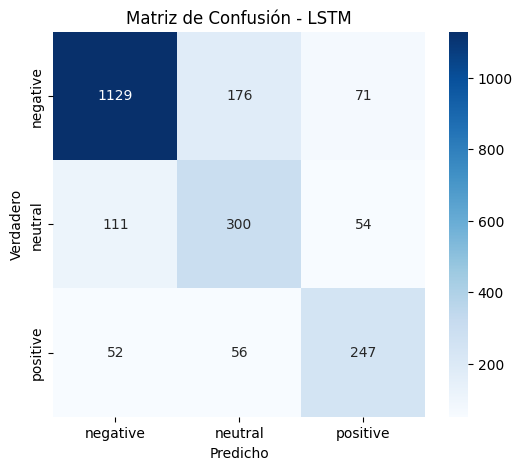

In [ ]:
def evaluar_modelo(model, X_test, Y_test, title):
    Y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(Y_pred, axis=1)
    y_true = np.argmax(Y_test, axis=1)

    print(f"\n--- Reporte de Clasificación: {title} ---")
    # Obtener nombres de columnas originales del get_dummies
    target_names = pd.get_dummies(df['airline_sentiment']).columns.tolist()

    print(classification_report(y_true, y_pred_classes, target_names=target_names))

    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Matriz de Confusión - {title}')
    plt.ylabel('Verdadero')
    plt.xlabel('Predicho')
    plt.show()

evaluar_modelo(model_rnn, X_test, Y_test, "RNN Simple")
evaluar_modelo(model_lstm, X_test, Y_test, "LSTM")